Jena Climate Datasetに対して、さまざまな深層学習のモデルを用いて解析を行う。なお、時系列データである.
また、データが10分刻みであり、データ数がかなり多いので、日で平均をとって解析を行う.
Date timeが、strなので、datetimeに変えたのちに平均をとる

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [44]:
df=pd.read_csv("jena_climate_2009_2016.csv")
df.head(),df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  str    
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10  H2OC (mmol/mol)  420551 non-null  float64
 11  rho (g/m**3)     420551 non-null  float64
 12  wv (m/s)         420551 non-null  float64
 13  max. wv (m/s)    420551 non-null  float64
 14  wd (deg)         420551 non-null  float64
dtypes: float64(14), str(1)
memory usage: 48.1 MB


(             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
 0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
 1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
 2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
 3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
 4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   
 
    VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
 0          3.33          3.11          0.22       1.94             3.12   
 1          3.23          3.02          0.21       1.89             3.03   
 2          3.21          3.01          0.20       1.88             3.02   
 3          3.26          3.07          0.19       1.92             3.08   
 4          3.27          3.08          0.19       1.92             3.09   
 
    rho (g/m**3)  wv (m/s)  max. wv (m/s)  wd (deg)  
 0       1307.75  

In [45]:
df['day']=pd.to_datetime(df['Date Time'],dayfirst=True)
df.drop("Date Time",axis=1,inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   p (mbar)         420551 non-null  float64       
 1   T (degC)         420551 non-null  float64       
 2   Tpot (K)         420551 non-null  float64       
 3   Tdew (degC)      420551 non-null  float64       
 4   rh (%)           420551 non-null  float64       
 5   VPmax (mbar)     420551 non-null  float64       
 6   VPact (mbar)     420551 non-null  float64       
 7   VPdef (mbar)     420551 non-null  float64       
 8   sh (g/kg)        420551 non-null  float64       
 9   H2OC (mmol/mol)  420551 non-null  float64       
 10  rho (g/m**3)     420551 non-null  float64       
 11  wv (m/s)         420551 non-null  float64       
 12  max. wv (m/s)    420551 non-null  float64       
 13  wd (deg)         420551 non-null  float64       
 14  day              420551 non-nul

In [46]:
df_day = df.resample('D', on='day').mean().reset_index()
df_day.head()

,day,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01,999.145594,-6.810629,266.414545,-8.015594,91.086014,3.691119,3.355524,0.335315,2.091049,3.357832,1305.178252,0.778601,1.378252,181.863077
1,2009-01-02,999.600625,-3.728194,269.463194,-4.824861,92.086806,4.640069,4.267292,0.373056,2.659792,4.268750,1290.353194,1.419514,2.227361,125.072014
2,2009-01-03,998.548611,-5.271736,268.002292,-9.015833,76.458056,4.184792,3.107708,1.077014,1.937778,3.111944,1297.117014,1.250903,2.065069,190.383333
3,2009-01-04,988.510694,-1.375208,272.685347,-2.897014,89.417361,5.524306,4.938958,0.584861,3.114028,4.997014,1264.634514,1.720417,3.564861,213.069861
4,2009-01-05,990.405694,-4.867153,269.039306,-6.797292,86.260417,4.362708,3.806736,0.555625,2.397014,3.847778,1284.372778,3.800278,5.940000,118.287361


欠損値および、重複の確認

In [47]:
df_day.isna().sum()

day                0
p (mbar)           2
T (degC)           2
Tpot (K)           2
Tdew (degC)        2
rh (%)             2
VPmax (mbar)       2
VPact (mbar)       2
VPdef (mbar)       2
sh (g/kg)          2
H2OC (mmol/mol)    2
rho (g/m**3)       2
wv (m/s)           2
max. wv (m/s)      2
wd (deg)           2
dtype: int64

In [48]:
df_nan_rows = df_day[df_day.isnull().any(axis=1)]
df_nan_rows

,day,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
2855,2016-10-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2856,2016-10-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
dup_count = df_day['day'].duplicated().sum()
dup_count

np.int64(0)

In [50]:
ideal_range = pd.date_range(start=df_day['day'].min(), end=df_day['day'].max(), freq='D')
df_indexed = df_day.set_index('day').reindex(ideal_range)
missing_dates = df_indexed[df_indexed.isnull().any(axis=1)].index
missing_dates

DatetimeIndex(['2016-10-26', '2016-10-27'], dtype='datetime64[us]', freq='D')

In [51]:
df_nonan = df_indexed.interpolate(method='linear')
df_nonan.isnull().sum()

p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

In [52]:
df_p=df_nonan.reset_index().rename({'index':"day"},axis=1)
df_p

,day,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01,999.145594,-6.810629,266.414545,-8.015594,91.086014,3.691119,3.355524,0.335315,2.091049,3.357832,1305.178252,0.778601,1.378252,181.863077
1,2009-01-02,999.600625,-3.728194,269.463194,-4.824861,92.086806,4.640069,4.267292,0.373056,2.659792,4.268750,1290.353194,1.419514,2.227361,125.072014
2,2009-01-03,998.548611,-5.271736,268.002292,-9.015833,76.458056,4.184792,3.107708,1.077014,1.937778,3.111944,1297.117014,1.250903,2.065069,190.383333
3,2009-01-04,988.510694,-1.375208,272.685347,-2.897014,89.417361,5.524306,4.938958,0.584861,3.114028,4.997014,1264.634514,1.720417,3.564861,213.069861
4,2009-01-05,990.405694,-4.867153,269.039306,-6.797292,86.260417,4.362708,3.806736,0.555625,2.397014,3.847778,1284.372778,3.800278,5.940000,118.287361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2918,2016-12-28,1013.542986,4.887153,276.979444,2.408542,84.070833,8.672500,7.269583,1.403264,4.473264,7.171875,1266.425556,2.558194,4.726597,254.427708
2919,2016-12-29,1013.957569,2.676250,274.744583,1.246458,90.384722,7.447569,6.705833,0.741250,4.123889,6.613542,1277.391528,0.837986,1.394028,196.642639
2920,2016-12-30,1010.460278,-1.706597,270.647361,-2.727292,92.927083,5.465764,5.048542,0.416458,3.113889,4.996875,1294.402639,1.138125,1.839306,201.359028
2921,2016-12-31,1004.476181,-2.492500,270.323681,-6.548472,74.360694,5.226111,3.765069,1.460972,2.335069,3.749444,1291.183472,0.803403,1.453542,194.592153


簡単にplotしてみる。
季節性は当然明らかにあることが分かる。また、どの年のピークも大体は一緒であるが、最低は、バラツキがある印象

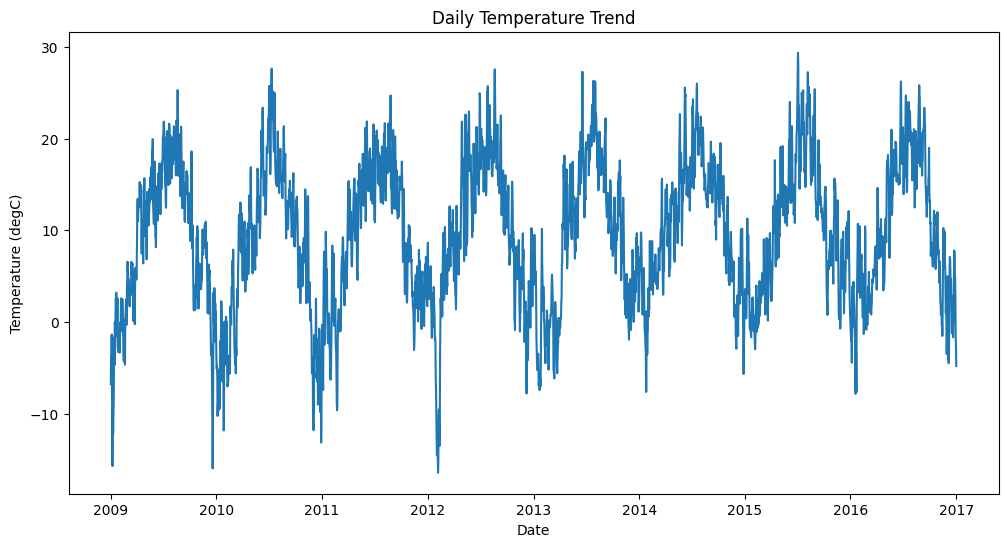

In [53]:
plt.figure(figsize=(12, 6))
plt.plot(df_p['day'], df_p['T (degC)'])
plt.title('Daily Temperature Trend')
plt.xlabel('Date')
plt.ylabel('Temperature (degC)')
plt.show()

ここからモデルに使う変数の吟味を行う。一般に統計モデルほど、多重共線性を意識する必要がないが、計算コストおよび、過学習の防止の観点から、高いものに関しては消していく。(Tpot (K), Tdew (degC)、VPmax (mbar), VPact (mbar), VPdef (mbar), sh (g/kg), H2OC (mmol/mol),max. wv (m/s))
また、日にちに関しては、sin,cos変換を行う.wdにかんしてもradianに変更、その後、風の強さを、方向に分解、こうすることで機械学習できる形にする

In [54]:
timestamp_s = df_p.day.map(pd.Timestamp.timestamp) 
timestamp_s

0       1.230768e+09
1       1.230854e+09
2       1.230941e+09
3       1.231027e+09
4       1.231114e+09
            ...     
2918    1.482883e+09
2919    1.482970e+09
2920    1.483056e+09
2921    1.483142e+09
2922    1.483229e+09
Name: day, Length: 2923, dtype: float64

In [55]:
day_seconds = 24 * 60 * 60
year_seconds = (365.2425) * day_seconds
df_p['Year_sin'] = np.sin(timestamp_s * (2 * np.pi / year_seconds))
df_p['Year_cos'] = np.cos(timestamp_s * (2 * np.pi / year_seconds))
wd_rad = df_p['wd (deg)'] * np.pi / 180
df_p['Wx'] = df_p['wv (m/s)'] * np.cos(wd_rad)
df_p['Wy'] = df_p['wv (m/s)'] * np.sin(wd_rad)

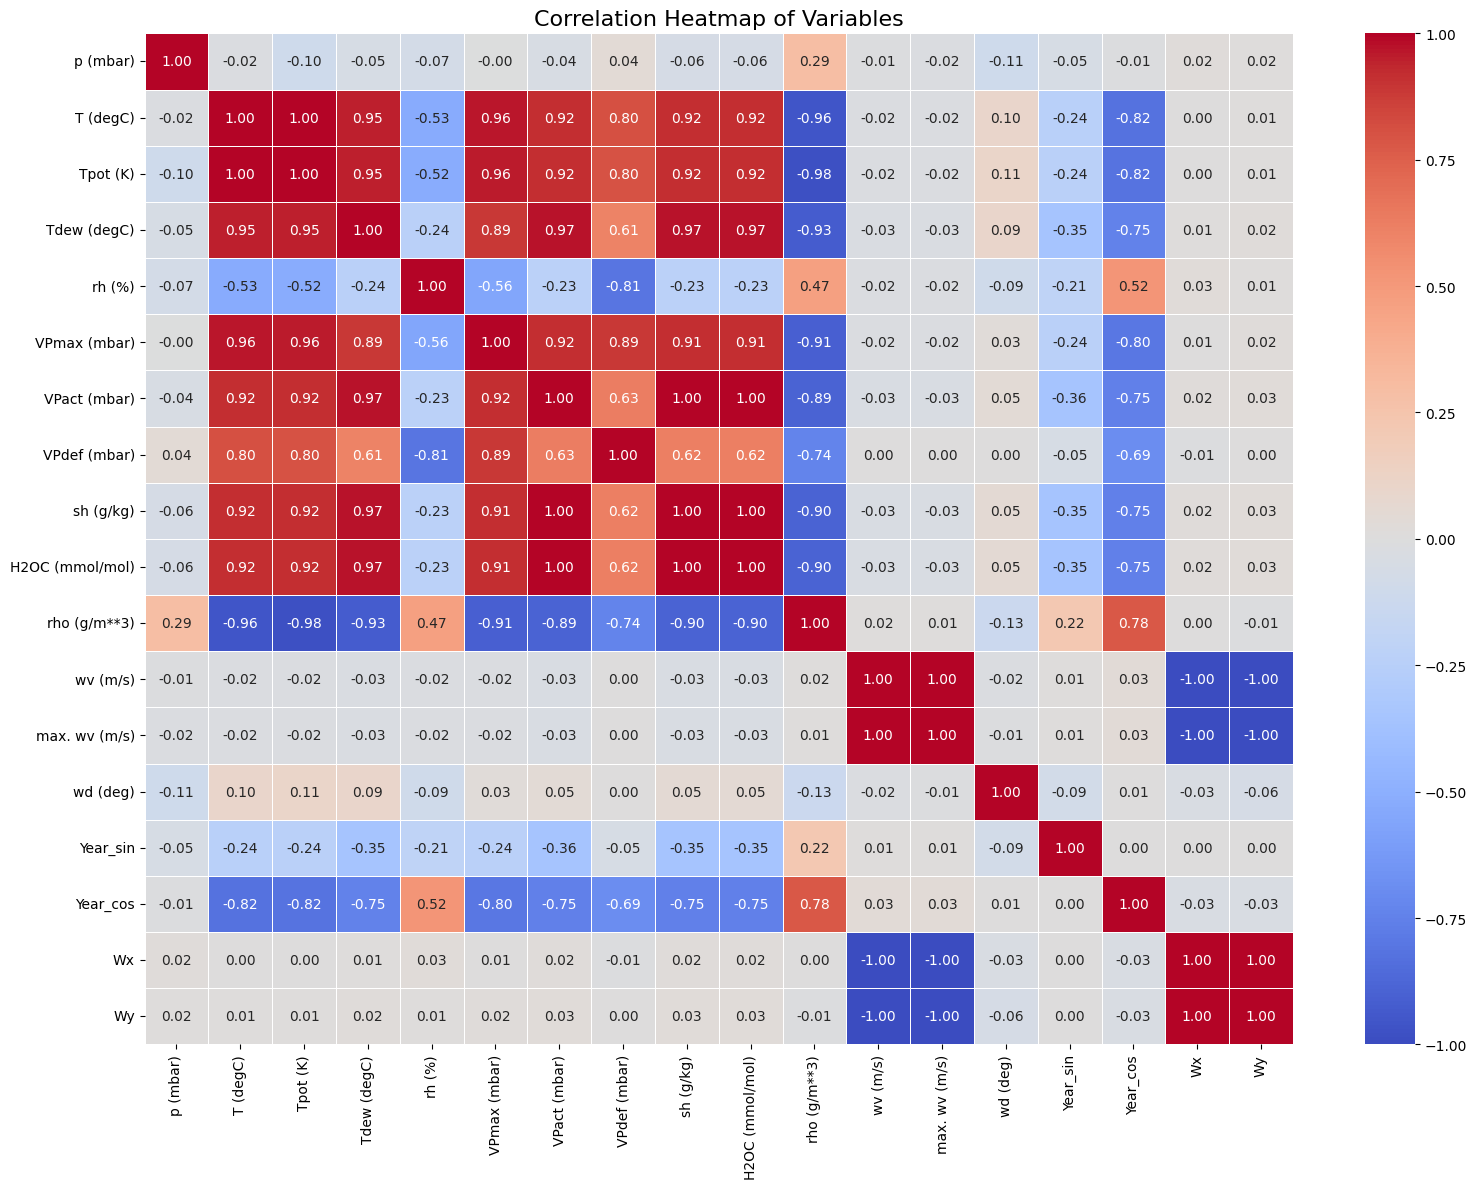

In [56]:
import seaborn as sns
numeric_df = df_p.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# 3. ヒートマップの設定と描画
plt.figure(figsize=(16, 12)) 

sns.heatmap(
    corr_matrix, 
    annot=True,        
    cmap='coolwarm',  
    vmin=-1, vmax=1,   
    fmt=".2f",         
    linewidths=.5     
)

plt.title('Correlation Heatmap of Variables', fontsize=16)
plt.tight_layout()
plt.show()

In [57]:
cols_to_drop = [
    'day', 
    'wv (m/s)', 'max. wv (m/s)', 'wd (deg)',
    'Tpot (K)', 'Tdew (degC)',
    'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)'
]
df_final = df_p.drop(columns=cols_to_drop)

In [58]:
df_final

,p (mbar),T (degC),rh (%),rho (g/m**3),Year_sin,Year_cos,Wx,Wy
0,999.145594,-6.810629,91.086014,1305.178252,0.009332,0.999956,-0.778190,-0.025313
1,999.600625,-3.728194,92.086806,1290.353194,0.026532,0.999648,-0.815661,1.161773
2,998.548611,-5.271736,76.458056,1297.117014,0.043724,0.999044,-1.230418,-0.225454
3,988.510694,-1.375208,89.417361,1264.634514,0.060903,0.998144,-1.441719,-0.938765
4,990.405694,-4.867153,86.260417,1284.372778,0.078064,0.996948,-1.800929,3.346456
...,...,...,...,...,...,...,...,...
2918,1013.542986,4.887153,84.070833,1266.425556,-0.058413,0.998292,-0.686758,-2.464290
2919,1013.957569,2.676250,90.384722,1277.391528,-0.041232,0.999150,-0.802883,-0.240000
2920,1010.460278,-1.706597,92.927083,1294.402639,-0.024039,0.999711,-1.059955,-0.414518
2921,1004.476181,-2.492500,74.360694,1291.183472,-0.006838,0.999977,-0.777488,-0.202407


正規化および、データの分割

In [59]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
n = len(df_final)
train_df = df_final[0:int(n*0.7)]
val_df = df_final[int(n*0.7):int(n*0.9)]
test_df = df_final[int(n*0.9):]

scaler = StandardScaler()
scaler.fit(train_df)

train_scaled = scaler.transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

print("Trainデータの形状:", train_scaled.shape)
print("Valデータの形状:", val_scaled.shape)
print("Testデータの形状:", test_scaled.shape)

Trainデータの形状: (2046, 8)
Valデータの形状: (584, 8)
Testデータの形状: (293, 8)


予測に関して、今回は2週間をinputs,その後の2週間を予測するというモデルを作る。これはデータウィンドウ形式でデータセットの構築を行う

In [60]:
train_df = pd.DataFrame(train_scaled, columns=df_final.columns, index=train_df.index)
val_df = pd.DataFrame(val_scaled, columns=df_final.columns, index=val_df.index)
test_df = pd.DataFrame(test_scaled, columns=df_final.columns, index=test_df.index)

In [61]:
import torch
from torch.utils.data import Dataset, DataLoader
class data_load(Dataset):
    def __init__(self,df,input_width,label_width,shift,label_col=None):
        self.df=df
        self.input_width=input_width
        self.label_width=label_width
        self.total_window_size=input_width+shift
        self.label_columns=label_col
        if label_col is not None:
            col_ind={name:i for i,name in  enumerate(df.columns)}
            self.lab_ind=[col_ind[name] for name in self.label_columns]
        self.data = torch.tensor(df.values.astype('float32'))
    def __len__(self):
        return len(self.data)-self.total_window_size+1
    
    def __getitem__(self, i):
        window=self.data[i:i+self.total_window_size]
        inputs = window[:self.input_width, :]
        label_start = self.total_window_size - self.label_width
        labels = window[label_start:, :]
        if self.label_columns is not None:
            labels=labels[:,self.lab_ind]
        return inputs,labels

def create_dataloader(df, input_width=7, label_width=7, shift=7, batch_size=32, shuffle=False):
    dataset = data_load(
        df=df, 
        input_width=input_width, 
        label_width=label_width, 
        shift=shift, 
        label_col=label_cols  
    )
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    
    return dataloader

In [62]:
label_cols=['T (degC)']
train_loader = create_dataloader(
    df=train_df,       
    input_width=14, 
    label_width=14, 
    shift=14, 
    batch_size=32, 
    shuffle=True
)
val_loader = create_dataloader(
    df=val_df,       
    input_width=14, 
    label_width=14, 
    shift=14, 
    batch_size=32, 
    shuffle=False
)
test_loader = create_dataloader(
    df=test_df,       
    input_width=14, 
    label_width=14, 
    shift=14, 
    batch_size=32, 
    shuffle=False
)

形の確認

In [63]:
inputs, labels = next(iter(train_loader))
print(f"Inputsの形: {inputs.shape}")
print(f"Labelsの形: {labels.shape}")
inputs=inputs.cpu().numpy()
labels=labels.cpu().numpy()

Inputsの形: torch.Size([32, 14, 8])
Labelsの形: torch.Size([32, 14, 1])


モデル１とモデル２を作る.内容としてはDNN。ここで、DropoutやBatchNormは今回の解析では行わない。どこかでどれほど汎化性が上がるのかや、学習速度に関してのまとめを行う.
モデル１、２の違い
モデル1:過去のステップ*8つの特徴量をすべて一次元にしてから入力
モデル2:データのテンソルの形を保ったまま計算を行う

In [64]:
import torch.nn as nn
import torch.optim as optim
model1=nn.Sequential(
    nn.Flatten(),
    nn.Linear(14*8,512),
    nn.ReLU(),
    nn.Linear(512,512),
    nn.ReLU(),
    nn.Linear(512,14)
)
model2= nn.Sequential(
    nn.Linear(8, 64),   
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 1),    
)


損失関数の設定は、Huber Lossを用いている。
そして、最適化に関してはadamを用いて更新している(勾配降下法と違ってモーメントを利用する)

In [65]:
model1.to("cuda")
#loss_fn=nn.MSELoss()
loss_fn = nn.HuberLoss(delta=0.3)
optimizer=optim.Adam(model1.parameters(),lr=0.001)
[param.shape for param in model1.parameters()]
sum([param.numel() for param in model1.parameters()])

327694

モデル１の訓練からしていく。
Early Stoppingは５で検証

In [66]:
import torch

epoch = 50
patience = 5  
epochs_no_improve = 0
best_val_loss = float('inf')  
best_model_path = "best_model1.pth" 

for i in range(epoch):
    model1.train()
    total_train_loss = 0
    for inputs, labels in train_loader:
        inputs = inputs.to("cuda")
        labels = labels.to("cuda")
        
        outputs = model1(inputs)
        loss = loss_fn(outputs.unsqueeze(-1), labels) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    model1.eval()  
    total_val_loss = 0
    
    with torch.no_grad():  
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to("cuda")
            val_labels = val_labels.to("cuda")
            
            val_outputs = model1(val_inputs)
            val_loss = loss_fn(val_outputs.unsqueeze(-1), val_labels)
            
            total_val_loss += val_loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    
    print(f"Epoch {i+1}/{epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model1.state_dict(), best_model_path)
        print("ベストモデルを更新")
    else:
        epochs_no_improve += 1
        print(f"Val Loss改善せず (Patience: {epochs_no_improve}/{patience})")
        if epochs_no_improve >= patience:
            print(f"\n【Early Stopping】 Epoch {i+1} で学習を早期終了します。")
            break
model1.load_state_dict(torch.load(best_model_path))

Epoch 1/50 | Train Loss: 0.0880 | Val Loss: 0.1387
ベストモデルを更新
Epoch 2/50 | Train Loss: 0.0715 | Val Loss: 0.1766
Val Loss改善せず (Patience: 1/5)
Epoch 3/50 | Train Loss: 0.0690 | Val Loss: 0.1606
Val Loss改善せず (Patience: 2/5)
Epoch 4/50 | Train Loss: 0.0647 | Val Loss: 0.1748
Val Loss改善せず (Patience: 3/5)
Epoch 5/50 | Train Loss: 0.0608 | Val Loss: 0.1805
Val Loss改善せず (Patience: 4/5)
Epoch 6/50 | Train Loss: 0.0571 | Val Loss: 0.2210
Val Loss改善せず (Patience: 5/5)

【Early Stopping】 Epoch 6 で学習を早期終了します。


<All keys matched successfully>

In [67]:
with torch.no_grad():
    model1.eval()
    test_loss1=0
    for inputs,labels in test_loader:
        inputs=inputs.to("cuda")
        labels=labels.to("cuda")
        outputs=model1(inputs)
        loss=loss_fn(outputs.unsqueeze(-1),labels)
        test_loss1+=loss.item()
    test_loss1=test_loss1/len(test_loader)
test_loss1

0.07082689594891337

実際にこの誤差の値がよいのか否かはほかのモデルのとの比較をしないとわからない。
いったん、4バッチ分をplotしてみた。
結果としてはピーク点を捉えにいくこともできておらず、また、値が大きく変わる瞬間を予測することもできていない（横ばいの予測）

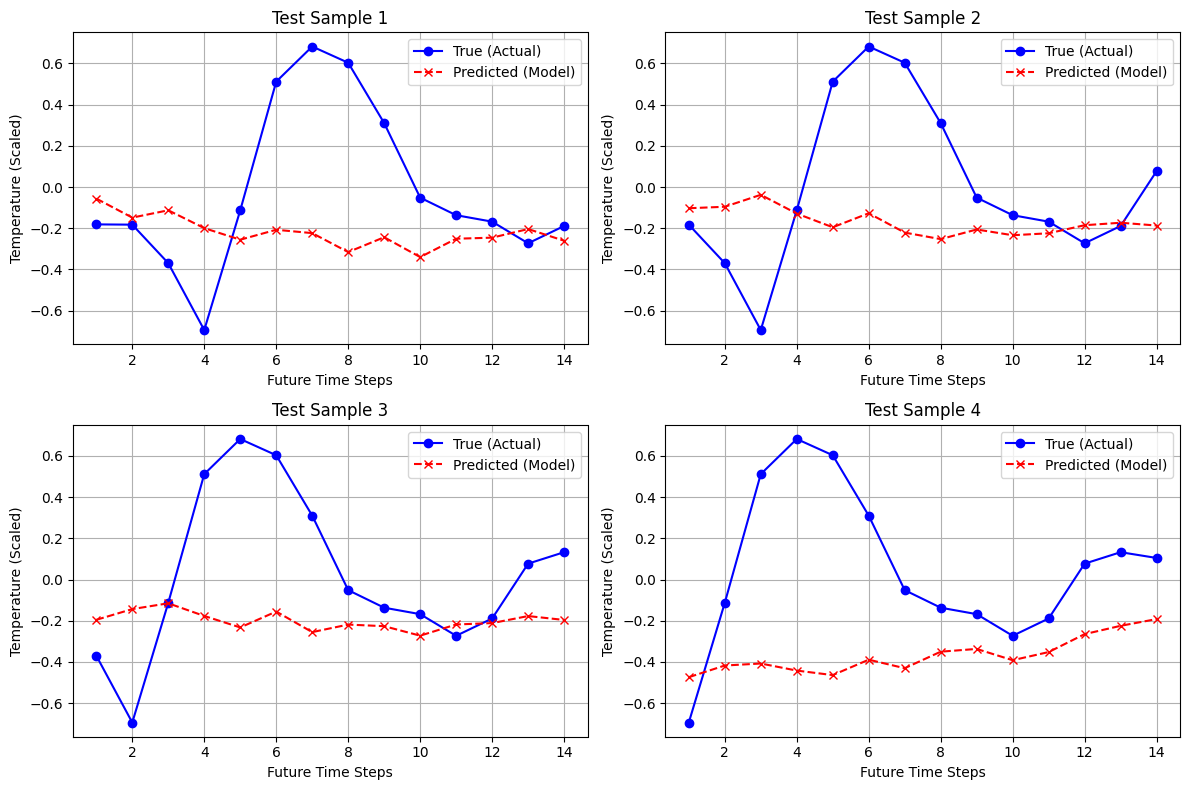

In [68]:
model1.eval()
inputs, labels = next(iter(test_loader))
inputs = inputs.to("cuda")
labels = labels.to("cuda")
with torch.no_grad():
    preds = model1(inputs)

labels_np = labels.cpu().numpy()
preds_np = preds.cpu().numpy()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(4):
    true_temps = labels_np[i].flatten()
    pred_temps = preds_np[i].flatten()
    x_steps = range(1, 15)
    axes[i].plot(x_steps, true_temps, label='True (Actual)', marker='o', color='blue')
    axes[i].plot(x_steps, pred_temps, label='Predicted (Model)', marker='x', linestyle='--', color='red')
    axes[i].set_title(f"Test Sample {i+1}")
    axes[i].set_xlabel("Future Time Steps")
    axes[i].set_ylabel("Temperature (Scaled)")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [69]:
model2.to("cuda")
optimizer = optim.Adam(model2.parameters(), lr=0.001)
import torch

epoch = 50
patience = 5  
epochs_no_improve = 0
best_val_loss = float('inf')  
best_model_path = "best_model2.pth" 

for i in range(epoch):
    model2.train()  
    total_train_loss = 0
    for inputs, labels in train_loader:
        inputs = inputs.to("cuda")
        labels = labels.to("cuda")
        
        outputs = model2(inputs) 
        loss = loss_fn(outputs, labels) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    
    model2.eval()  
    total_val_loss = 0
    
    with torch.no_grad():  
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to("cuda")
            val_labels = val_labels.to("cuda")
            
            val_outputs = model2(val_inputs)
            val_loss = loss_fn(val_outputs, val_labels)
            
            total_val_loss += val_loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    
    print(f"Epoch {i+1}/{epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model2.state_dict(), best_model_path) 
        print("ベストモデルを更新")
    else:
        epochs_no_improve += 1
        print(f"Val Loss改善せず (Patience: {epochs_no_improve}/{patience})")
        if epochs_no_improve >= patience:
            print(f"\n【Early Stopping】 Epoch {i+1} で学習を早期終了します。")
            break

model2.load_state_dict(torch.load(best_model_path))

Epoch 1/50 | Train Loss: 0.1154 | Val Loss: 0.0823
ベストモデルを更新
Epoch 2/50 | Train Loss: 0.0818 | Val Loss: 0.0799
ベストモデルを更新
Epoch 3/50 | Train Loss: 0.0786 | Val Loss: 0.0955
Val Loss改善せず (Patience: 1/5)
Epoch 4/50 | Train Loss: 0.0781 | Val Loss: 0.0883
Val Loss改善せず (Patience: 2/5)
Epoch 5/50 | Train Loss: 0.0759 | Val Loss: 0.1034
Val Loss改善せず (Patience: 3/5)
Epoch 6/50 | Train Loss: 0.0750 | Val Loss: 0.1012
Val Loss改善せず (Patience: 4/5)
Epoch 7/50 | Train Loss: 0.0742 | Val Loss: 0.0910
Val Loss改善せず (Patience: 5/5)

【Early Stopping】 Epoch 7 で学習を早期終了します。


<All keys matched successfully>

損失は、モデル1に比べて悪い。plotしてみても、ほぼ、モデル１と似たような感じになっている。

In [70]:
with torch.no_grad():
    model2.eval()
    test_loss2=0
    for inputs,labels in test_loader:
        inputs=inputs.to("cuda")
        labels=labels.to("cuda")
        outputs=model2(inputs)
        loss=loss_fn(outputs,labels)
        test_loss2+=loss.item()
    test_loss2=test_loss2/len(test_loader)
test_loss2

0.07346387124723858

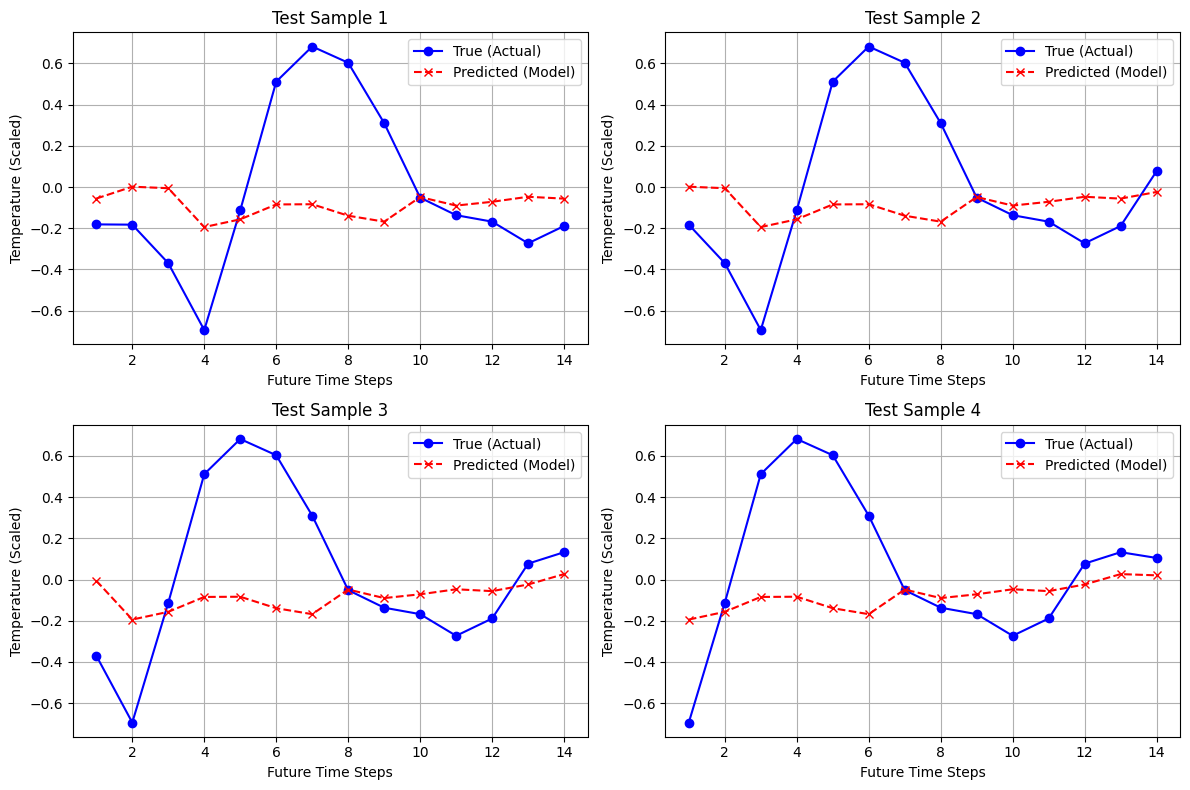

In [71]:
model2.eval()
inputs, labels = next(iter(test_loader))
inputs = inputs.to("cuda")
labels = labels.to("cuda")
with torch.no_grad():
    preds = model2(inputs)

labels_np = labels.cpu().numpy()
preds_np = preds.cpu().numpy()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(4):
    true_temps = labels_np[i].flatten()
    pred_temps = preds_np[i].flatten()
    x_steps = range(1, 15)
    axes[i].plot(x_steps, true_temps, label='True (Actual)', marker='o', color='blue')
    axes[i].plot(x_steps, pred_temps, label='Predicted (Model)', marker='x', linestyle='--', color='red')
    axes[i].set_title(f"Test Sample {i+1}")
    axes[i].set_xlabel("Future Time Steps")
    axes[i].set_ylabel("Temperature (Scaled)")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

CNNでモデルを作ってみる

In [72]:
import math
class time_ser(nn.Module):
    def __init__(self,in_cha,conv_cha):#入力が[32,14,8]
        super().__init__()
        self.conv1=nn.Conv1d(in_cha,conv_cha,kernel_size=3,padding=1,bias=True)
        self.relu1=nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(conv_cha, conv_cha, kernel_size=3, padding=1, bias=True)
        self.relu2 = nn.ReLU(inplace=True)
        self.avgpool = nn.AvgPool1d(2, 2) #最後の次元に作用,maxもある
    
    def forward(self,input):
        block_out=self.conv1(input)
        block_out=self.relu1(block_out)
        block_out=self.conv2(block_out)
        block_out=self.relu2(block_out)
        return self.avgpool(block_out)

class time_NN(nn.Module):
      def __init__(self,in_cha,conv_cha):
          super().__init__()
          self.block1 = time_ser(in_cha, conv_cha)
          self.block2 = time_ser(conv_cha, conv_cha*2) 
          self.head_linear = nn.Linear(64*3, 14)
          self._init_weights()

      def _init_weights(self):
        for m in self.modules():
            if type(m) in {nn.Linear, nn.Conv1d}:
                nn.init.kaiming_normal_(
                    m.weight.data, a=0, mode='fan_out', nonlinearity='relu',
                )#平均0の正規分布からランダムに選ぶ
                if m.bias is not None:
                    fan_in, fan_out = nn.init._calculate_fan_in_and_fan_out(m.weight.data)
                    bound = 1 / math.sqrt(fan_out)
                    nn.init.uniform_(m.bias, -bound, bound)
      def forward(self, input_batch):
            input_batch = input_batch.permute(0, 2, 1)#次元置き換え,特徴量が真ん中に来るように設定
            block_out = self.block1(input_batch)  # [B, 32, 7]
            block_out = self.block2(block_out)  # [B, 64, 3]
            conv_flat = block_out.view(block_out.size(0), -1) # [B, 96]
            linear_output = self.head_linear(conv_flat)      
            kekka=linear_output.unsqueeze(-1)
            return kekka
      

In [73]:
model3= time_NN(in_cha=8, conv_cha=32).to("cuda")
loss_fn = nn.HuberLoss(delta=0.3)
optimizer = optim.Adam(model3.parameters(), lr=0.001)

epoch = 50
patience = 5  
epochs_no_improve = 0
best_val_loss = float('inf')  
best_model_path = "best_model3.pth" 

for i in range(epoch):
    model3.train()  
    total_train_loss = 0
    for inputs, labels in train_loader:
        inputs = inputs.to("cuda")
        labels = labels.to("cuda")
        
        outputs = model3(inputs) 
        loss = loss_fn(outputs, labels) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    
    model3.eval()  
    total_val_loss = 0
    
    with torch.no_grad():  
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to("cuda")
            val_labels = val_labels.to("cuda")
            
            val_outputs = model3(val_inputs)
            val_loss = loss_fn(val_outputs, val_labels)
            
            total_val_loss += val_loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    
    print(f"Epoch {i+1}/{epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model3.state_dict(), best_model_path) 
        print("ベストモデルを更新")
    else:
        epochs_no_improve += 1
        print(f"Val Loss改善せず (Patience: {epochs_no_improve}/{patience})")
        if epochs_no_improve >= patience:
            print(f"\n【Early Stopping】 Epoch {i+1} で学習を早期終了します。")
            break

model3.load_state_dict(torch.load(best_model_path))


Epoch 1/50 | Train Loss: 0.1354 | Val Loss: 0.2733
ベストモデルを更新
Epoch 2/50 | Train Loss: 0.0816 | Val Loss: 0.2297
ベストモデルを更新
Epoch 3/50 | Train Loss: 0.0772 | Val Loss: 0.2303
Val Loss改善せず (Patience: 1/5)
Epoch 4/50 | Train Loss: 0.0712 | Val Loss: 0.2415
Val Loss改善せず (Patience: 2/5)
Epoch 5/50 | Train Loss: 0.0674 | Val Loss: 0.2335
Val Loss改善せず (Patience: 3/5)
Epoch 6/50 | Train Loss: 0.0631 | Val Loss: 0.2385
Val Loss改善せず (Patience: 4/5)
Epoch 7/50 | Train Loss: 0.0591 | Val Loss: 0.2374
Val Loss改善せず (Patience: 5/5)

【Early Stopping】 Epoch 7 で学習を早期終了します。


<All keys matched successfully>

In [74]:
with torch.no_grad():
    model3.eval()
    test_loss3=0
    for inputs,labels in test_loader:
        inputs=inputs.to("cuda")
        labels=labels.to("cuda")
        outputs=model3(inputs)
        loss=loss_fn(outputs,labels)
        test_loss3+=loss.item()
    test_loss3=test_loss3/len(test_loader)
test_loss3

0.07755760765737957

誤差はほぼ変わらず。ただし、予測がギザギザになっているので、最大、最小のピーク点を追おうとしているのは分かる。

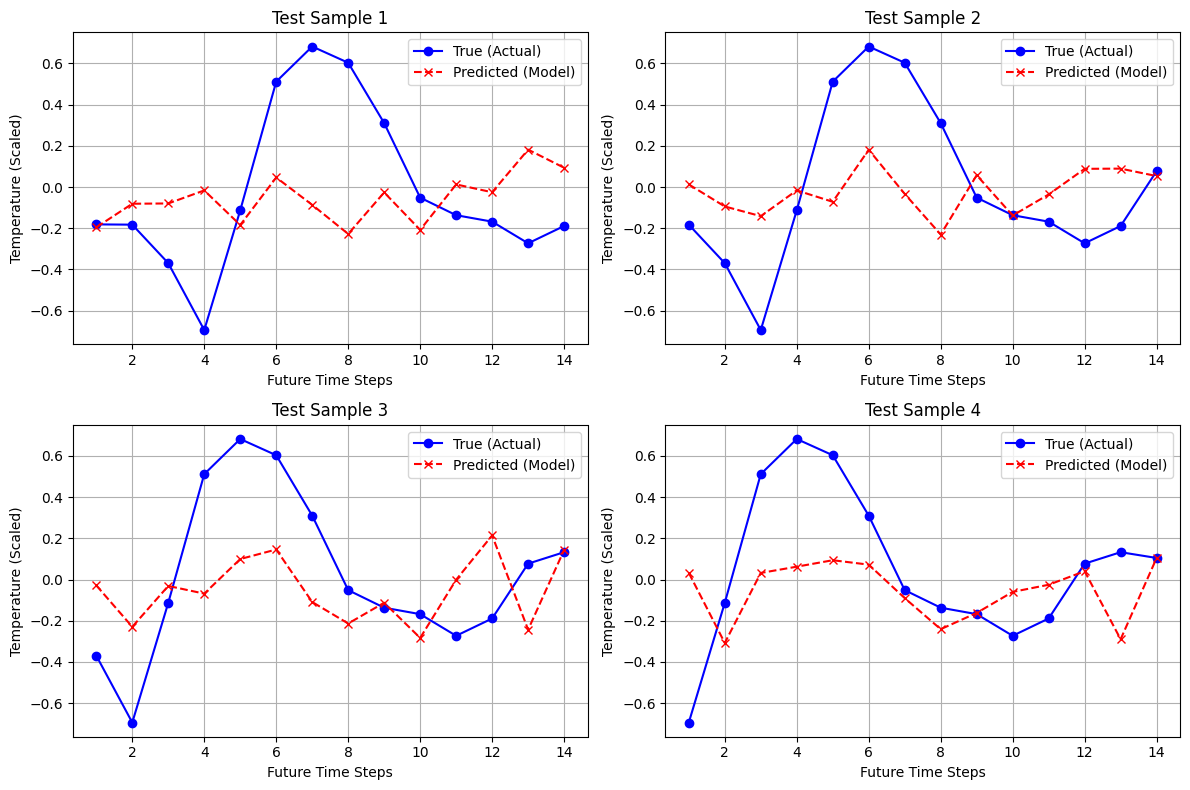

In [75]:
model3.eval()
inputs, labels = next(iter(test_loader))
inputs = inputs.to("cuda")
labels = labels.to("cuda")
with torch.no_grad():
    preds = model3(inputs)

labels_np = labels.cpu().numpy()
preds_np = preds.cpu().numpy()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(4):
    true_temps = labels_np[i].flatten()
    pred_temps = preds_np[i].flatten()
    x_steps = range(1, 15)
    axes[i].plot(x_steps, true_temps, label='True (Actual)', marker='o', color='blue')
    axes[i].plot(x_steps, pred_temps, label='Predicted (Model)', marker='x', linestyle='--', color='red')
    axes[i].set_title(f"Test Sample {i+1}")
    axes[i].set_xlabel("Future Time Steps")
    axes[i].set_ylabel("Temperature (Scaled)")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

最後に本命のlstm

In [76]:
inputs.size()

torch.Size([32, 14, 8])

In [77]:
class lstm_one(nn.Module):
    def __init__(self,input_size=8,hidden_size=64,num_layer=1):
        super().__init__()
        self.lstm=nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layer,
            batch_first=True#[32,14,8]では本来32を時間だと思う
        )

        self.head_linear=nn.Linear(hidden_size,14)#[32,14]

    def forward(self,x):
        lstm_out,(h_n,c_n)=self.lstm(x)#h_nは、[2,32,64],受け取りたいのは[32,64]で、２は２個ある、そのうちの一個だけでいい
        linear_out=self.head_linear(h_n[-1])
        result = linear_out.unsqueeze(-1)
        return result


In [78]:
model4= lstm_one().to("cuda")
loss_fn = nn.HuberLoss(delta=0.3)
optimizer = optim.Adam(model4.parameters(), lr=0.001)

epoch = 50
patience = 5  
epochs_no_improve = 0
best_val_loss = float('inf')  
best_model_path = "best_model4.pth" 

for i in range(epoch):
    model4.train()  
    total_train_loss = 0
    for inputs, labels in train_loader:
        inputs = inputs.to("cuda")
        labels = labels.to("cuda")
        
        outputs = model4(inputs) 
        loss = loss_fn(outputs, labels) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    
    model4.eval()  
    total_val_loss = 0
    
    with torch.no_grad():  
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to("cuda")
            val_labels = val_labels.to("cuda")
            
            val_outputs = model4(val_inputs)
            val_loss = loss_fn(val_outputs, val_labels)
            
            total_val_loss += val_loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    
    print(f"Epoch {i+1}/{epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model4.state_dict(), best_model_path) 
        print("ベストモデルを更新")
    else:
        epochs_no_improve += 1
        print(f"Val Loss改善せず (Patience: {epochs_no_improve}/{patience})")
        if epochs_no_improve >= patience:
            print(f"\n【Early Stopping】 Epoch {i+1} で学習を早期終了します。")
            break

model4.load_state_dict(torch.load(best_model_path))

Epoch 1/50 | Train Loss: 0.1326 | Val Loss: 0.0808
ベストモデルを更新
Epoch 2/50 | Train Loss: 0.0787 | Val Loss: 0.0759
ベストモデルを更新
Epoch 3/50 | Train Loss: 0.0752 | Val Loss: 0.0744
ベストモデルを更新
Epoch 4/50 | Train Loss: 0.0732 | Val Loss: 0.0767
Val Loss改善せず (Patience: 1/5)
Epoch 5/50 | Train Loss: 0.0725 | Val Loss: 0.0801
Val Loss改善せず (Patience: 2/5)
Epoch 6/50 | Train Loss: 0.0698 | Val Loss: 0.0787
Val Loss改善せず (Patience: 3/5)
Epoch 7/50 | Train Loss: 0.0694 | Val Loss: 0.0786
Val Loss改善せず (Patience: 4/5)
Epoch 8/50 | Train Loss: 0.0686 | Val Loss: 0.0790
Val Loss改善せず (Patience: 5/5)

【Early Stopping】 Epoch 8 で学習を早期終了します。


<All keys matched successfully>

In [79]:
with torch.no_grad():
    model4.eval()
    test_loss4=0
    for inputs,labels in test_loader:
        inputs=inputs.to("cuda")
        labels=labels.to("cuda")
        outputs=model4(inputs)
        loss=loss_fn(outputs,labels)
        test_loss4+=loss.item()
    test_loss4=test_loss4/len(test_loader)
test_loss4

0.06879843523104985

誤差は一番いいが、横ばい予測のため、あまりいいとは言えない。

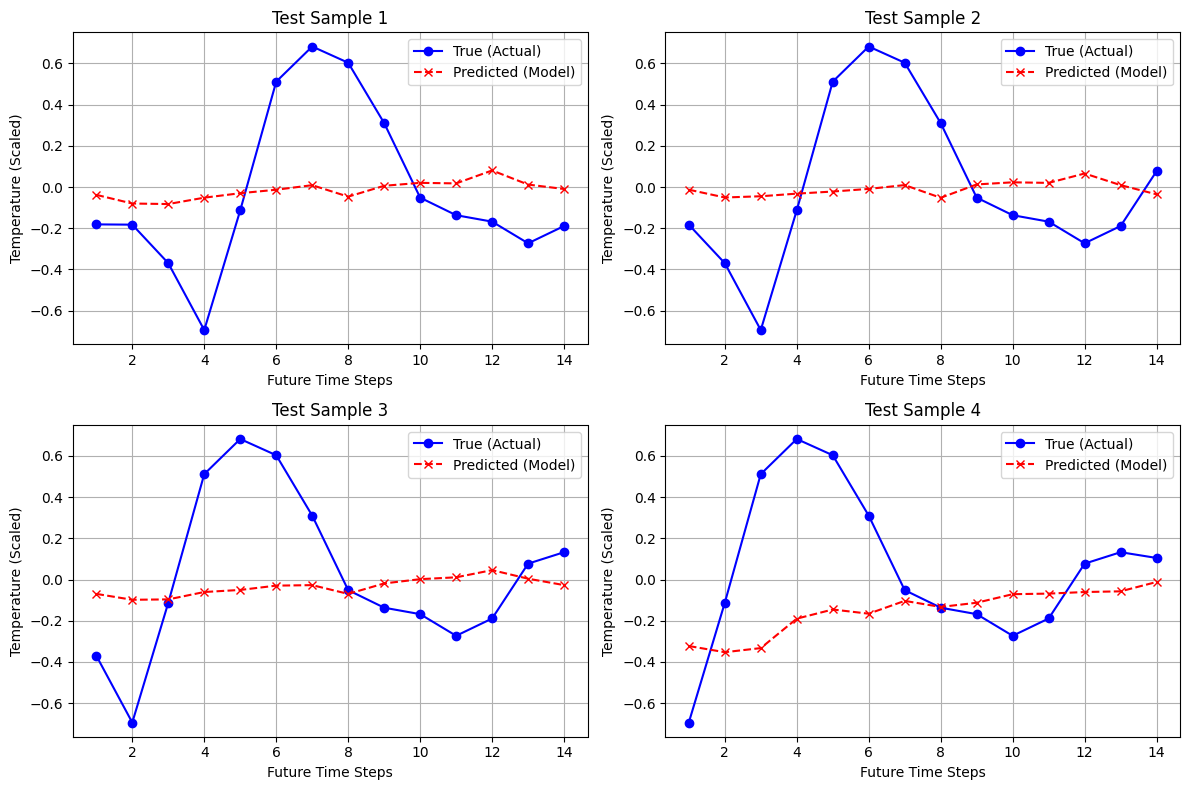

In [80]:
model4.eval()
inputs, labels = next(iter(test_loader))
inputs = inputs.to("cuda")
labels = labels.to("cuda")
with torch.no_grad():
    preds = model4(inputs)

labels_np = labels.cpu().numpy()
preds_np = preds.cpu().numpy()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(4):
    true_temps = labels_np[i].flatten()
    pred_temps = preds_np[i].flatten()
    x_steps = range(1, 15)
    axes[i].plot(x_steps, true_temps, label='True (Actual)', marker='o', color='blue')
    axes[i].plot(x_steps, pred_temps, label='Predicted (Model)', marker='x', linestyle='--', color='red')
    axes[i].set_title(f"Test Sample {i+1}")
    axes[i].set_xlabel("Future Time Steps")
    axes[i].set_ylabel("Temperature (Scaled)")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [81]:
class lstm_many(nn.Module):
    def __init__(self,input_size=8,hidden_size=64,num_layer=2):#many to many(入力１から、出力１を予測、２から２)
        super().__init__()
        self.lstm=nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layer,
            batch_first=True
        )

        self.head_linear=nn.Linear(hidden_size,1)

    def forward(self,x):
        lstm_out,(h_n,c_n)=self.lstm(x)#h_nは最新の記憶、c_Nは長期記憶,lstm_outが２４時間to２４時間の予測
        result=self.head_linear(lstm_out) #[32,14,64]
        return result
    

In [82]:
model5= lstm_many().to("cuda")
loss_fn = nn.HuberLoss(delta=0.3)
optimizer = optim.Adam(model5.parameters(), lr=0.001)

epoch = 50
patience = 5  
epochs_no_improve = 0
best_val_loss = float('inf')  
best_model_path = "best_model5.pth" 

for i in range(epoch):
    model5.train()  
    total_train_loss = 0
    for inputs, labels in train_loader:
        inputs = inputs.to("cuda")
        labels = labels.to("cuda")
        
        outputs = model5(inputs) 
        loss = loss_fn(outputs, labels) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    
    model5.eval()  
    total_val_loss = 0
    
    with torch.no_grad():  
        for val_inputs, val_labels in val_loader:
            val_inputs = val_inputs.to("cuda")
            val_labels = val_labels.to("cuda")
            
            val_outputs = model5(val_inputs)
            val_loss = loss_fn(val_outputs, val_labels)
            
            total_val_loss += val_loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    
    print(f"Epoch {i+1}/{epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model5.state_dict(), best_model_path) 
        print("ベストモデルを更新")
    else:
        epochs_no_improve += 1
        print(f"Val Loss改善せず (Patience: {epochs_no_improve}/{patience})")
        if epochs_no_improve >= patience:
            print(f"\n【Early Stopping】 Epoch {i+1} で学習を早期終了します。")
            break

model5.load_state_dict(torch.load(best_model_path))

Epoch 1/50 | Train Loss: 0.1257 | Val Loss: 0.0858
ベストモデルを更新
Epoch 2/50 | Train Loss: 0.0927 | Val Loss: 0.0817
ベストモデルを更新
Epoch 3/50 | Train Loss: 0.0869 | Val Loss: 0.0795
ベストモデルを更新
Epoch 4/50 | Train Loss: 0.0833 | Val Loss: 0.0771
ベストモデルを更新
Epoch 5/50 | Train Loss: 0.0801 | Val Loss: 0.0830
Val Loss改善せず (Patience: 1/5)
Epoch 6/50 | Train Loss: 0.0785 | Val Loss: 0.0845
Val Loss改善せず (Patience: 2/5)
Epoch 7/50 | Train Loss: 0.0762 | Val Loss: 0.0819
Val Loss改善せず (Patience: 3/5)
Epoch 8/50 | Train Loss: 0.0751 | Val Loss: 0.0796
Val Loss改善せず (Patience: 4/5)
Epoch 9/50 | Train Loss: 0.0741 | Val Loss: 0.0828
Val Loss改善せず (Patience: 5/5)

【Early Stopping】 Epoch 9 で学習を早期終了します。


<All keys matched successfully>

In [83]:
with torch.no_grad():
    model5.eval()
    test_loss5=0
    for inputs,labels in test_loader:
        inputs=inputs.to("cuda")
        labels=labels.to("cuda")
        outputs=model5(inputs)
        loss=loss_fn(outputs,labels)
        test_loss5+=loss.item()
    test_loss5=test_loss5/len(test_loader)
test_loss5

0.0798944127228525

横ばいの予測になっている。誤差もかなり悪い。

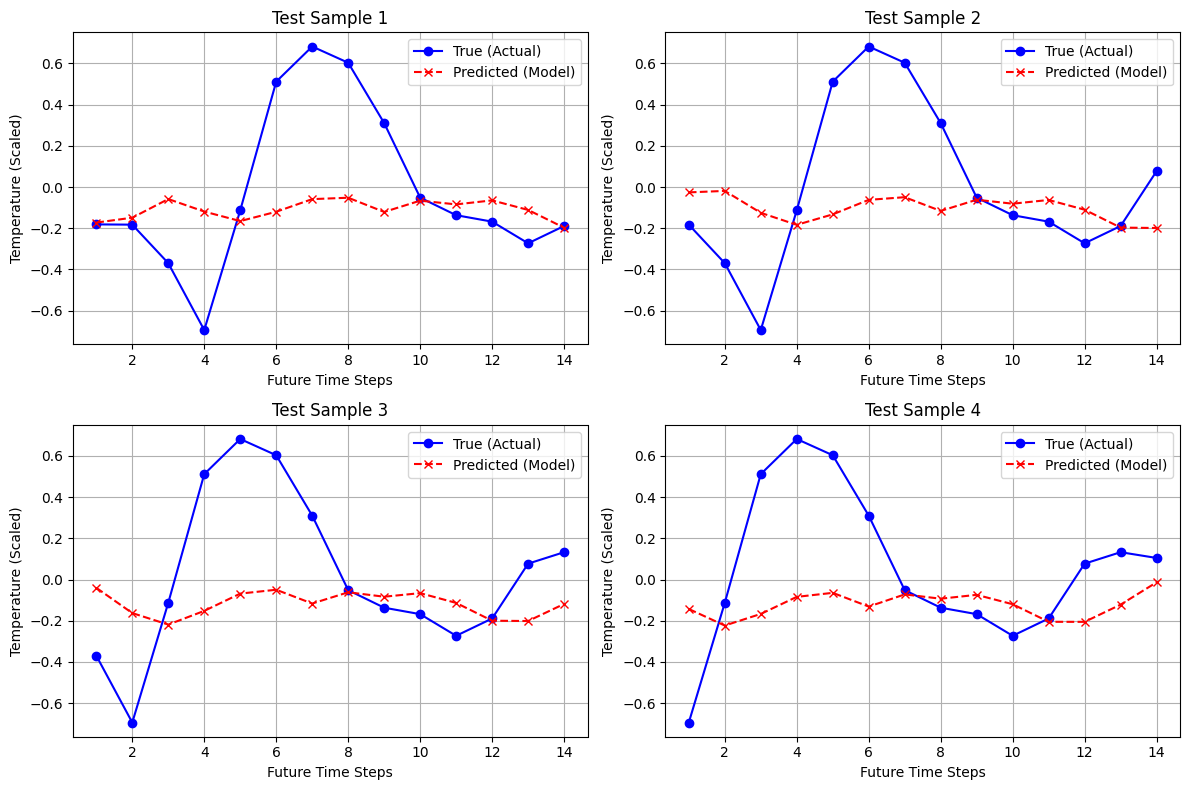

In [84]:
model5.eval()
inputs, labels = next(iter(test_loader))
inputs = inputs.to("cuda")
labels = labels.to("cuda")
with torch.no_grad():
    preds = model5(inputs)

labels_np = labels.cpu().numpy()
preds_np = preds.cpu().numpy()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(4):
    true_temps = labels_np[i].flatten()
    pred_temps = preds_np[i].flatten()
    x_steps = range(1, 15)
    axes[i].plot(x_steps, true_temps, label='True (Actual)', marker='o', color='blue')
    axes[i].plot(x_steps, pred_temps, label='Predicted (Model)', marker='x', linestyle='--', color='red')
    axes[i].set_title(f"Test Sample {i+1}")
    axes[i].set_xlabel("Future Time Steps")
    axes[i].set_ylabel("Temperature (Scaled)")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()